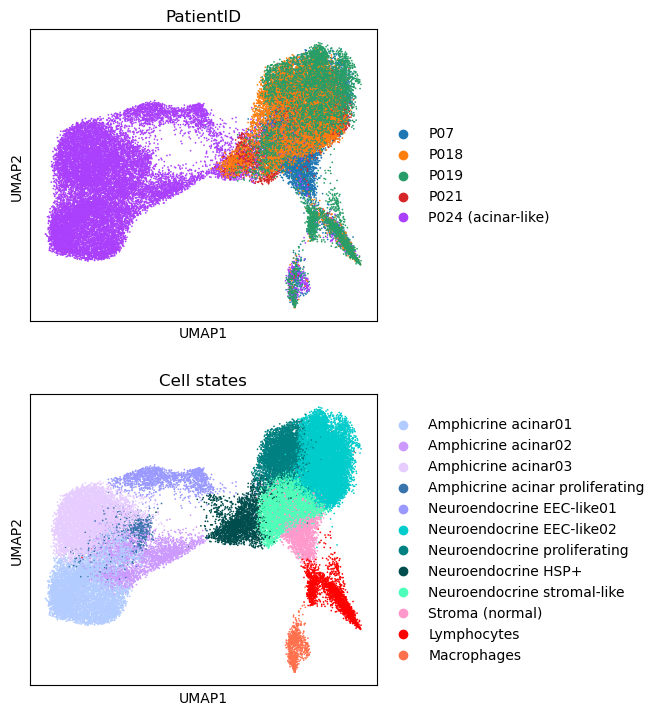

In [1]:
import scanpy as sc
import pandas as pd
import os

adata= sc.read_h5ad("./celltypist_benchmark/pNEC_updated_annot_07082023.h5ad")

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize']= (4,4)

sc.pl.umap(adata, color= ['PatientID', 'Cell states'], size=6, ncols=1)

In [2]:
#Rename PatientID labels
adata.obs['PatientID'] = adata.obs['PatientID'].replace({
    'P07': 'P1',
    'P018': 'P2',
    'P019': 'P3',
    'P021': 'P4',
    'P024 (acinar-like)': 'P5 (acinar)'
})


print(adata.obs['PatientID'].value_counts()) 

#Rename Cell states labels
adata.obs['Cell states'] = adata.obs['Cell states'].replace({
    'Neuroendocrine EEC-like01': 'Amphicrine progenitor-like',
    'Neuroendocrine EEC-like02': 'Neuroendocrine',
    'Neuroendocrine HSP+': 'Neuroendocrine HSP+ (hypoxic)'
})

print(adata.obs['Cell states'].value_counts()) 

PatientID
P5 (acinar)    19497
P1              8768
P2              8314
P3              5580
P4              2856
Name: count, dtype: int64
Cell states
Neuroendocrine                     10095
Amphicrine acinar01                 7047
Amphicrine acinar03                 5840
Neuroendocrine stromal-like         5668
Neuroendocrine proliferating        4033
Stroma (normal)                     2465
Amphicrine acinar02                 2424
Neuroendocrine HSP+ (hypoxic)       2275
Lymphocytes                         2124
Amphicrine progenitor-like          1488
Macrophages                          821
Amphicrine acinar proliferating      735
Name: count, dtype: int64


/tmp/ipykernel_205163/1365199625.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs['PatientID'] = adata.obs['PatientID'].replace({
/tmp/ipykernel_205163/1365199625.py:14: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs['Cell states'] = adata.obs['Cell states'].replace({


In [3]:
#Remove immune subsets:

adata_subset= adata[~adata.obs['Cell states'].isin(['Lymphocytes', 'Macrophages'])] 
adata_subset.obs['Cell states'].value_counts()

Cell states
Neuroendocrine                     10095
Amphicrine acinar01                 7047
Amphicrine acinar03                 5840
Neuroendocrine stromal-like         5668
Neuroendocrine proliferating        4033
Stroma (normal)                     2465
Amphicrine acinar02                 2424
Neuroendocrine HSP+ (hypoxic)       2275
Amphicrine progenitor-like          1488
Amphicrine acinar proliferating      735
Name: count, dtype: int64

In [4]:
#Normalize the subset: 
adata_norm= adata_subset.raw.to_adata()

sc.pp.normalize_total(adata_norm, target_sum=1e4)  #Normalize counts per cell
sc.pp.log1p(adata_norm)  #Log-transform the data

In [5]:
import matplotlib.pyplot as plt

In [6]:
#Define all receptor gene lists
glutamate_receptors = {
    'AMPA': ['GRIA1', 'GRIA2', 'GRIA3', 'GRIA4'],
    'NMDA': ['GRIN1', 'GRIN2A', 'GRIN2B', 'GRIN2C', 'GRIN2D', 'GRIN3A', 'GRIN3B'],
    'Kainate': ['GRIK1', 'GRIK2', 'GRIK3', 'GRIK4', 'GRIK5'],
    'mGluR': ['GRM1', 'GRM2', 'GRM3', 'GRM4', 'GRM5', 'GRM6', 'GRM7', 'GRM8']
}

gaba_receptors = {
    'GABAA_alpha': ['GABRA1', 'GABRA2', 'GABRA3', 'GABRA4', 'GABRA5', 'GABRA6'],
    'GABAA_beta': ['GABRB1', 'GABRB2', 'GABRB3'],
    'GABAA_gamma': ['GABRG1', 'GABRG2', 'GABRG3'],
    'GABAA_other': ['GABRD', 'GABRE', 'GABRP', 'GABRQ', 'GABRR1', 'GABRR2', 'GABRR3'],
    'GABAB': ['GABBR1', 'GABBR2']
}

glycine_receptors = ['GLRA1', 'GLRA2', 'GLRA3', 'GLRA4', 'GLRB']

#From Felix's first email- 28.05.2025
neuronal_markers = {
    'NeuN': ['RBFOX3'],
    'PSD_core': ['DLG4', 'DLG3', 'DLG2', 'DLG1'],
    'PSD_scaffolding': ['DLGAP1', 'DLGAP2', 'DLGAP3', 'DLGAP4', 
                        'SHANK1', 'SHANK2', 'SHANK3',
                        'HOMER1', 'HOMER2', 'HOMER3'],
    'PSD_GRIP': ['GRIP1', 'GRIP2'],
    'Synaptic': ['SYP', 'SYN1', 'SYN2']
}

#Flatten all genes into single lists for plotting
all_glutamate = [gene for sublist in glutamate_receptors.values() for gene in sublist]
all_gaba = [gene for sublist in gaba_receptors.values() for gene in sublist]
all_neuronal = [gene for sublist in neuronal_markers.values() for gene in sublist]

#Combine all genes
all_receptor_genes = all_glutamate + all_gaba + glycine_receptors + all_neuronal

Found 70 out of 70 genes in dataset


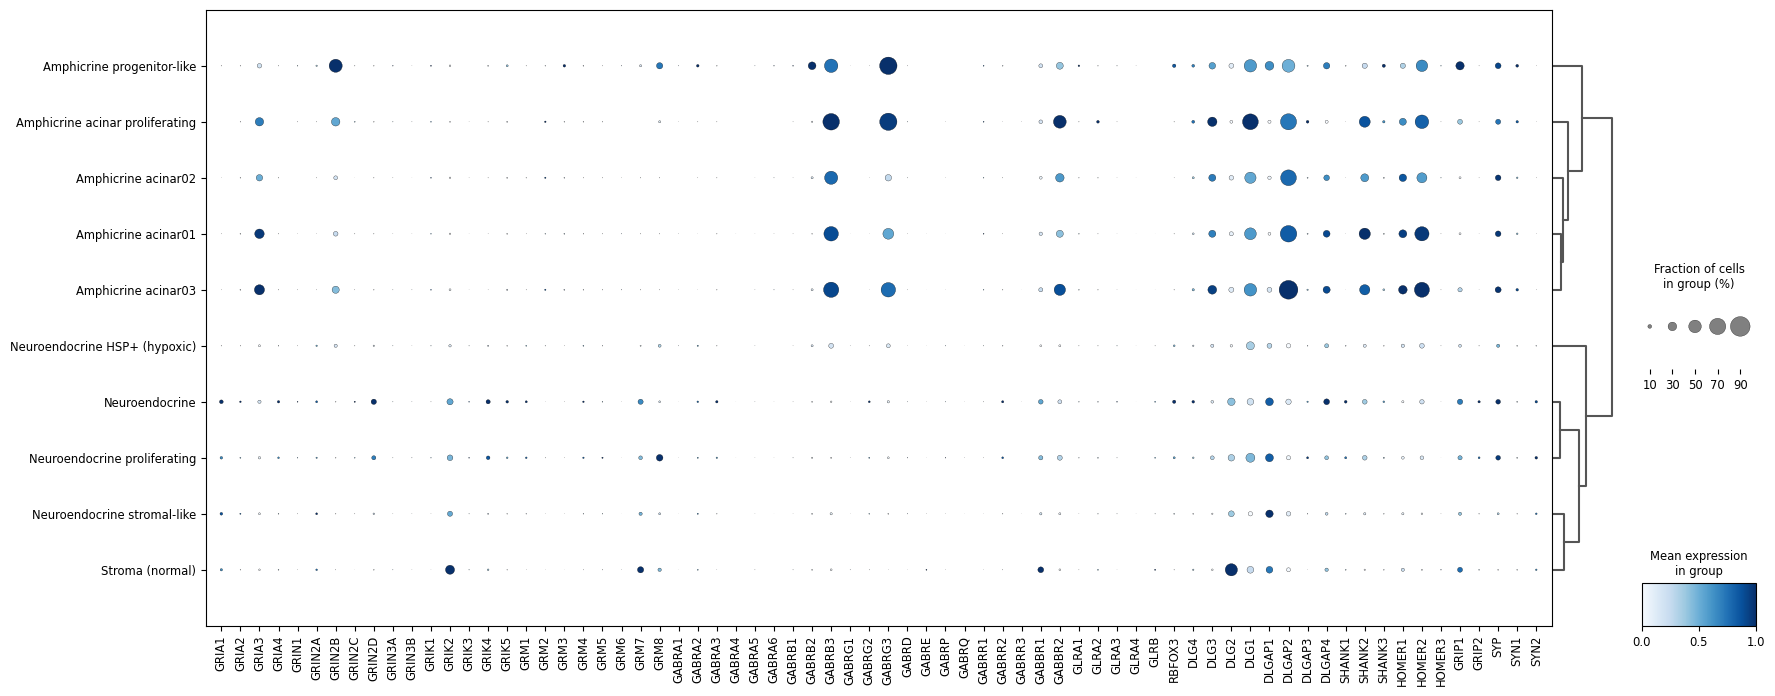

In [7]:
#Filter genes that are actually present in our dataset- prevents errors if some genes are not detected
available_genes = [g for g in all_receptor_genes if g in adata_norm.var_names]
print(f"Found {len(available_genes)} out of {len(all_receptor_genes)} genes in dataset")

#Create dotplot for all receptors grouped by cell type/cluster
#Adjust 'groupby' to annotation column (e.g., 'cell_type', 'leiden' etc)
sc.pl.dotplot(
    adata_norm,
    var_names=available_genes,
    groupby='Cell states',  
    dendrogram=True,  #Shows hierarchical clustering of cell types
    swap_axes=False,  #Genes on x-axis, cell types on y-axis
    standard_scale='var',  #Standardize expression per gene (z-score). Alternatively, don't scale 
    cmap='Blues',  #Color scheme
    figsize=(20, 8),  #Adjust size as needed
    save='_all_receptors_28052025.pdf'  #Saves to figures/ directory
)

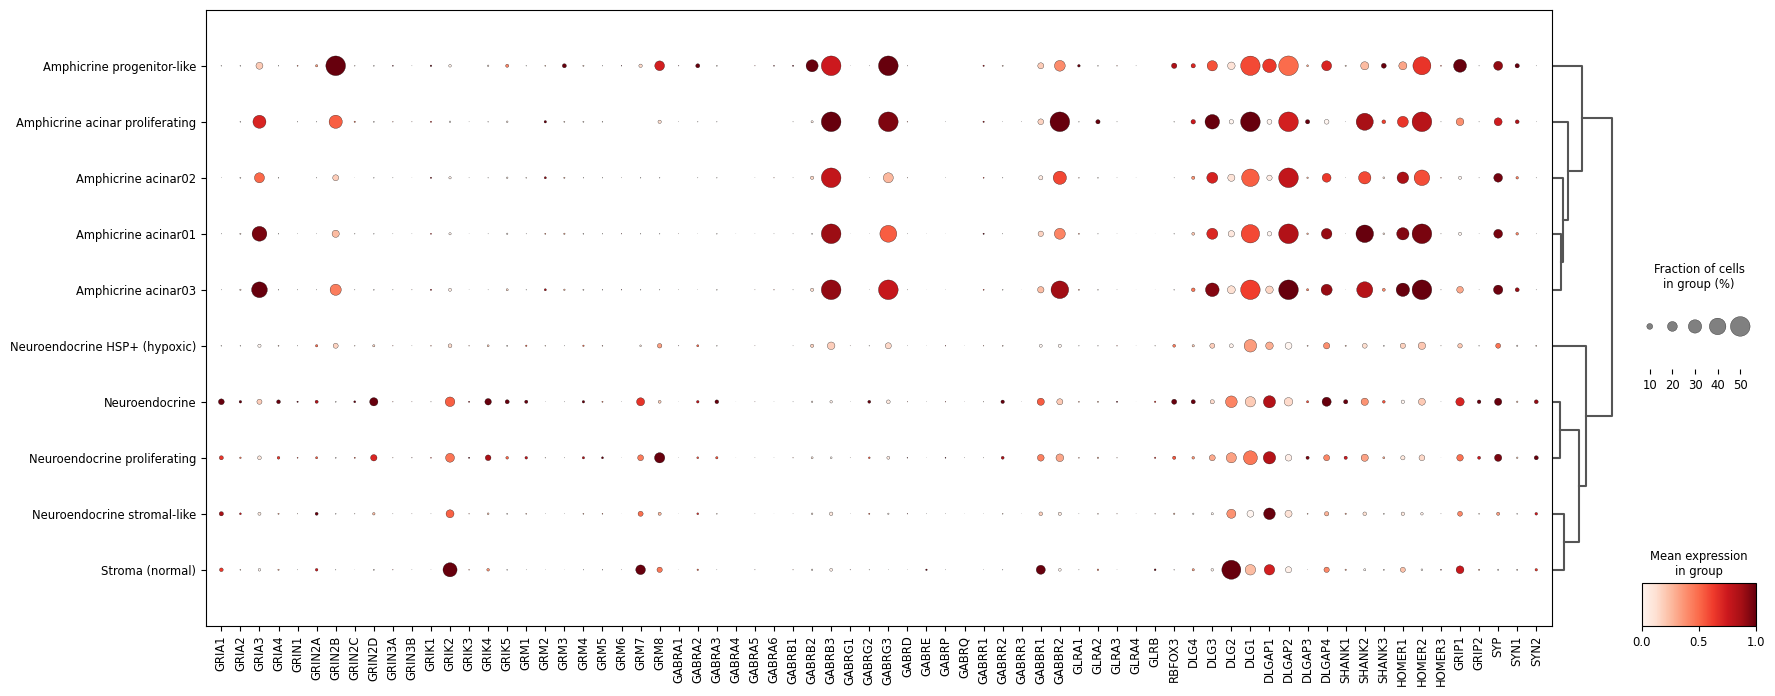

In [8]:
#Set maximum dot size to 50% to better see the shared NE clusters. 
sc.pl.dotplot(
    adata_norm,
    var_names=available_genes,
    groupby='Cell states',
    dendrogram=True,  #Shows hierarchical clustering of cell types
    swap_axes=False,  #Genes on x-axis, cell types on y-axis
    standard_scale='var',  #Standardize expression per gene (z-score)
    cmap='Reds',  #Color scheme
    figsize=(20, 8),  #Adjust size as needed
    dot_max= 0.5, 
    save='_all_receptors_v2_28052025.pdf'  #Saves to figures/ directory
)

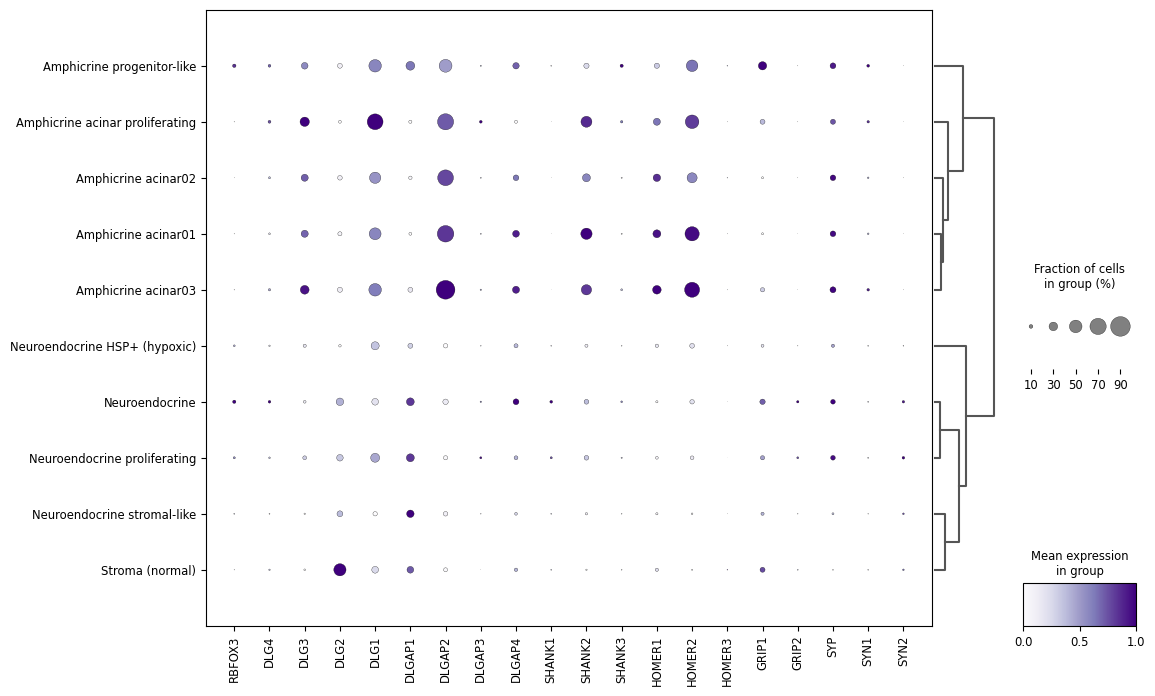

In [9]:
#Neuronal + synaptic markers
sc.pl.dotplot(
    adata_norm,
    var_names=[g for g in all_neuronal if g in adata_norm.var_names],
    groupby='Cell states',
    dendrogram=True,
    standard_scale='var',
    cmap='Purples',
    figsize=(12, 8),
    save='_neuronal_synaptic_markers_28052025.pdf'
)

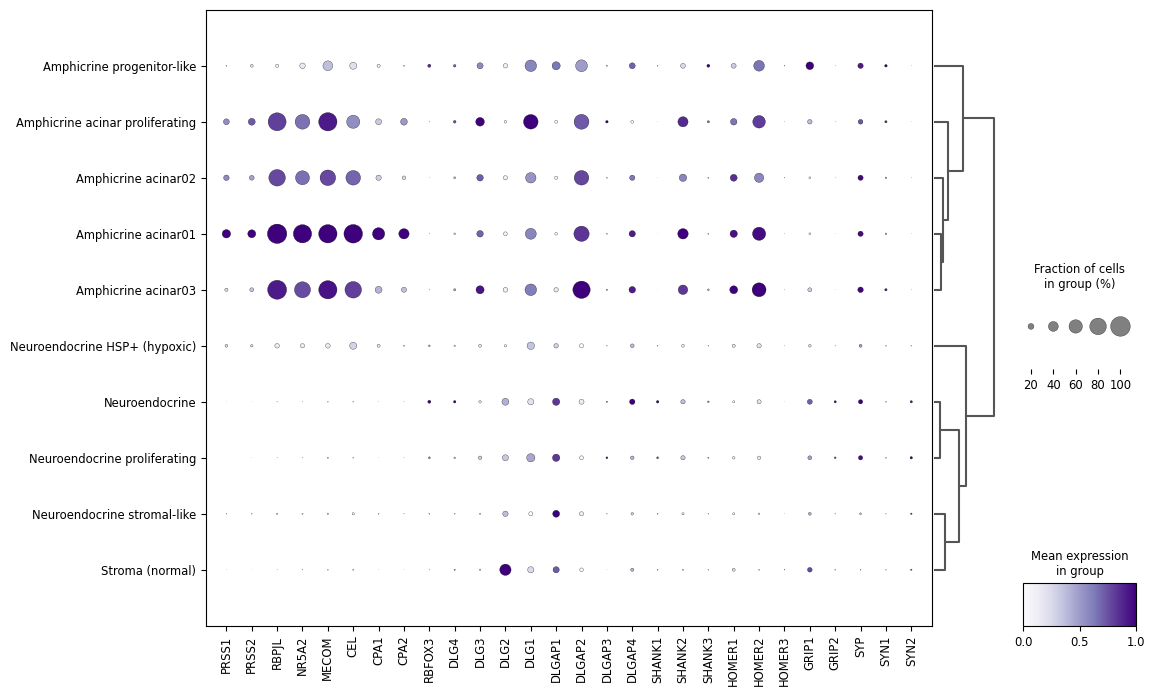

In [11]:
#Add pancreatic lineage specifying markers with synaptic for Felix
custom_markers = {'Pancreatic': ['PRSS1', 'PRSS2', 'RBPJL', 'NR5A2', 'MECOM', 'CEL', 'CPA1', 'CPA2'], 
    'NeuN': ['RBFOX3'],
    'PSD_core': ['DLG4', 'DLG3', 'DLG2', 'DLG1'],
    'PSD_scaffolding': ['DLGAP1', 'DLGAP2', 'DLGAP3', 'DLGAP4', 
                        'SHANK1', 'SHANK2', 'SHANK3',
                        'HOMER1', 'HOMER2', 'HOMER3'],
    'PSD_GRIP': ['GRIP1', 'GRIP2'],
    'Synaptic': ['SYP', 'SYN1', 'SYN2']
}


all_amph = [gene for sublist in custom_markers.values() for gene in sublist]

sc.pl.dotplot(
    adata_norm,
    var_names=[g for g in all_amph if g in adata_norm.var_names],
    groupby='Cell states',
    dendrogram=True,
    standard_scale='var',
    cmap='Purples',
    figsize=(12, 8)
)

#Amphicrine = pancreatic + NEC-like owing to synaptic/neuronal genes. 